In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'figure.facecolor': 'white'
})

RANDOM_STATE = 42  # for reproducibility
print('all libraries imported successfully!')

all libraries imported successfully!


In [56]:
import pandas as pd
file_path = "/kaggle/input/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025/tesla_deliveries_dataset_2015_2025.csv"
df = pd.read_csv(file_path)

print("Dataset loaded successfully!")
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

df.head()

Dataset loaded successfully!
Shape: (2640, 12)
Columns: ['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Source_Type', 'Charging_Stations']


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


In [57]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB


In [58]:
df.describe().round(2)

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.00,2640.00,2640.00,2640.00,2640.00,2640.00,2640.00,2640.00,2640.00
mean,2020.00,6.50,9922.20,10655.85,84907.34,87.06,500.26,744.08,8932.13
std,3.16,3.45,3935.95,4260.60,20123.26,20.84,120.87,353.22,3469.57
min,2015.00,1.00,48.00,50.00,50003.70,60.00,330.00,3.07,3002.00
25%,2017.00,3.75,7292.00,7828.25,67726.36,75.00,418.00,499.62,5897.75
50%,2020.00,6.50,9857.00,10546.50,85058.51,82.00,470.00,699.52,8901.50
75%,2023.00,9.25,12510.25,13469.00,102373.04,100.00,586.25,943.76,11938.00
max,2025.00,12.00,25704.00,28939.00,119965.36,120.00,719.00,2548.55,14996.00


In [59]:
for col in df.select_dtypes(include='object').columns:
    print(f'{col} -> {df[col].nunique()} unique values: {df[col].unique()}')

Region -> 4 unique values: ['Europe' 'Asia' 'North America' 'Middle East']
Model -> 5 unique values: ['Model S' 'Model X' 'Model 3' 'Model Y' 'Cybertruck']
Source_Type -> 3 unique values: ['Interpolated (Month)' 'Official (Quarter)' 'Estimated (Region)']


In [60]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)

if missing_df.empty:
    print('no missing values found, dataset is clean!')
else:
    print(missing_df)
    # plot it if there are missing values
    fig, ax = plt.subplots(figsize=(8, 4))
    missing_df['Missing %'].plot(kind='bar', ax=ax, color='tomato')
    ax.set_title('Missing Values by Column (%)')
    ax.set_ylabel('Missing %')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

no missing values found, dataset is clean!


In [61]:
n_dups = df.duplicated().sum()
print(f'duplicate rows found: {n_dups}')

if n_dups > 0:
    df.drop_duplicates(inplace=True)
    df.reset_index(drop=True, inplace=True)
    print(f'duplicates removed! new shape: {df.shape}')
else:
    print('no duplicates, good to go!')

duplicate rows found: 0
no duplicates, good to go!


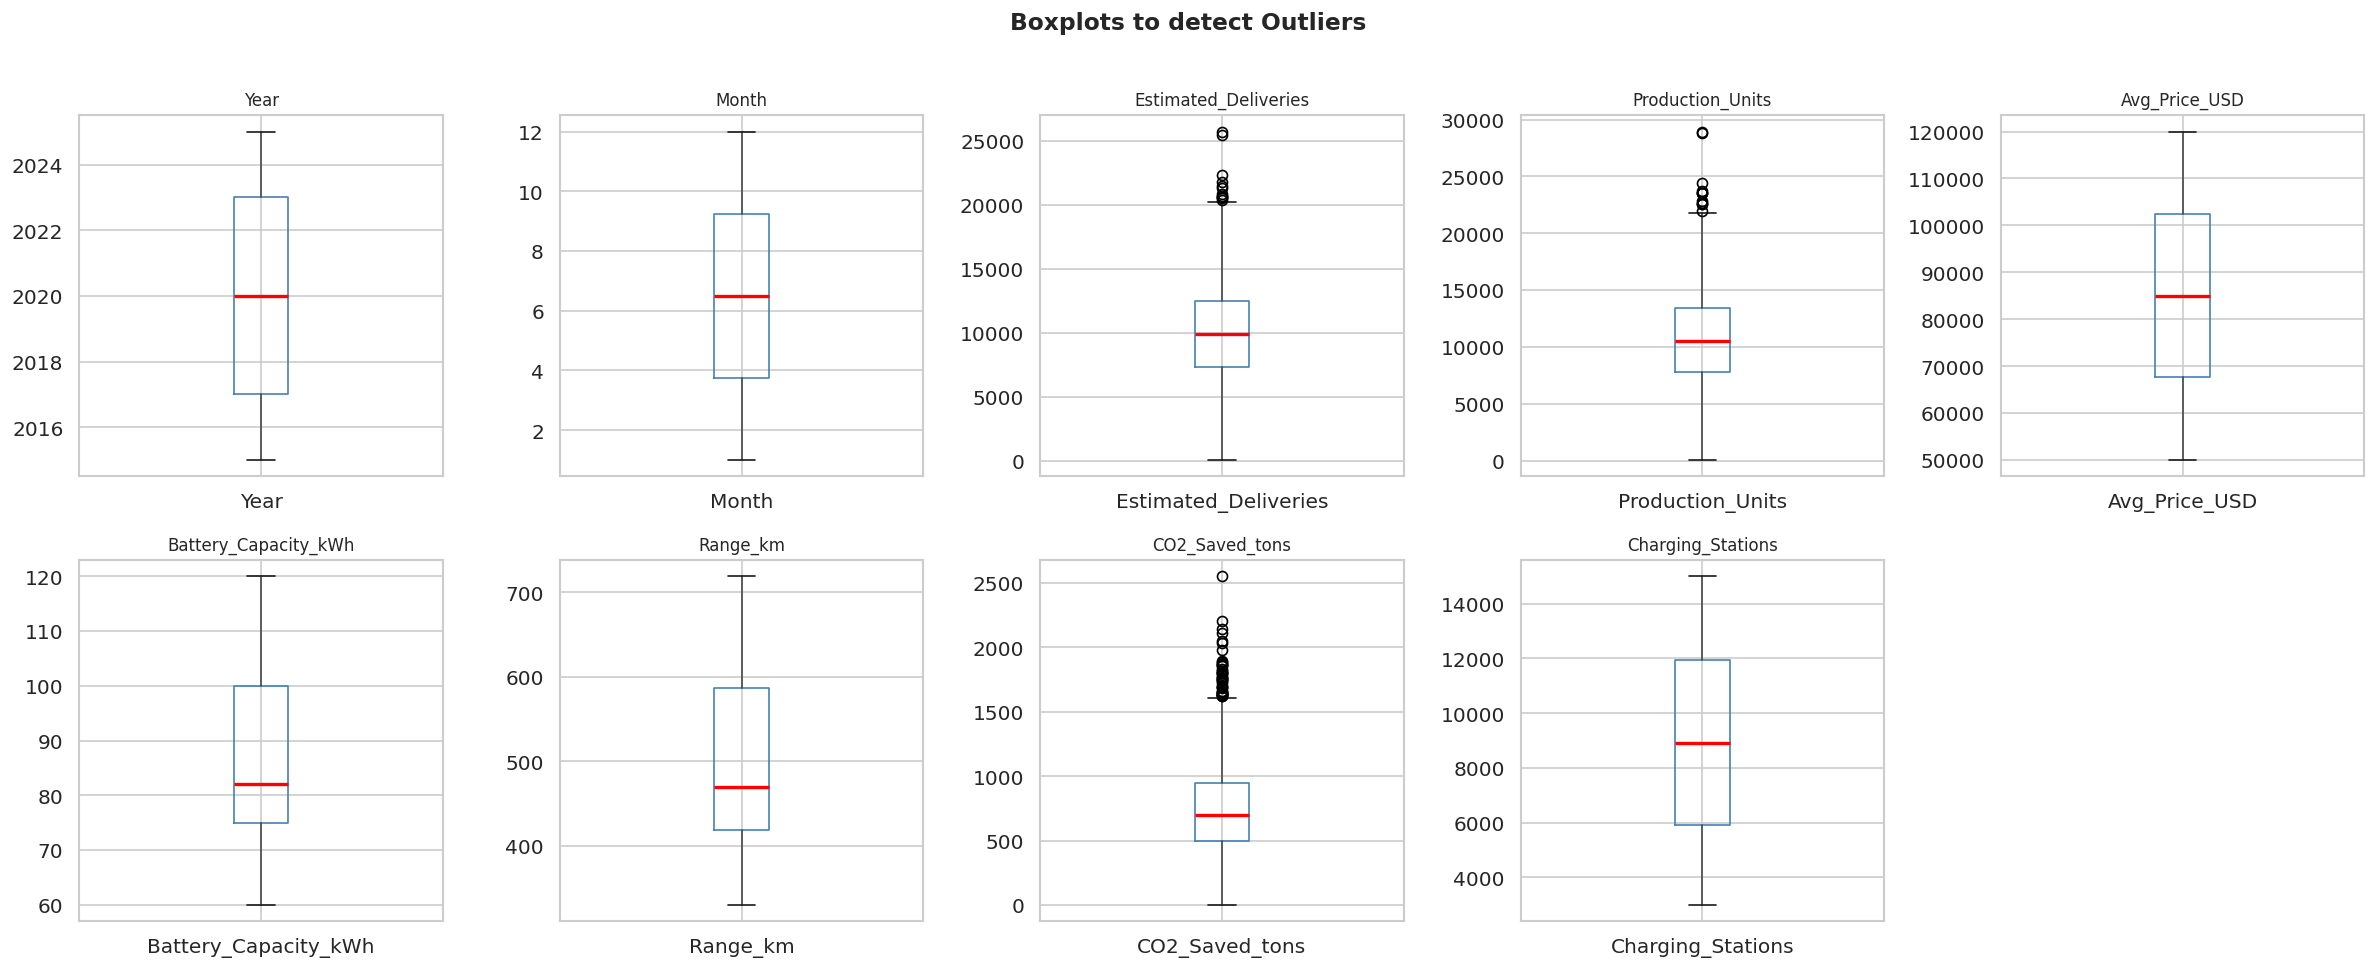

In [62]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols[:10]):
    df.boxplot(column=col, ax=axes[i],
               boxprops=dict(color='steelblue'),
               medianprops=dict(color='red', linewidth=2))
    axes[i].set_title(col, fontsize=10)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Boxplots to detect Outliers', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [63]:
outlier_report = []

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_report.append({
        'Column': col,
        'Outliers': n_out,
        'Pct': round(n_out / len(df) * 100, 2)
    })

outlier_df = pd.DataFrame(outlier_report).sort_values('Outliers', ascending=False)
print(outlier_df.to_string(index=False))
print('\nnote: not removing outliers here since they represent real delivery peaks in the data')

              Column  Outliers  Pct
      CO2_Saved_tons        45 1.70
    Production_Units        12 0.45
Estimated_Deliveries        12 0.45
                Year         0 0.00
               Month         0 0.00
       Avg_Price_USD         0 0.00
Battery_Capacity_kWh         0 0.00
            Range_km         0 0.00
   Charging_Stations         0 0.00

note: not removing outliers here since they represent real delivery peaks in the data


In [64]:
df['Date'] = pd.to_datetime(df[['Year', 'Month']].assign(day=1))

print('Date column created successfully')
print(df[['Year', 'Month', 'Date']].head(3))

Date column created successfully
   Year  Month       Date
0  2023      5 2023-05-01
1  2015      2 2015-02-01
2  2019      1 2019-01-01


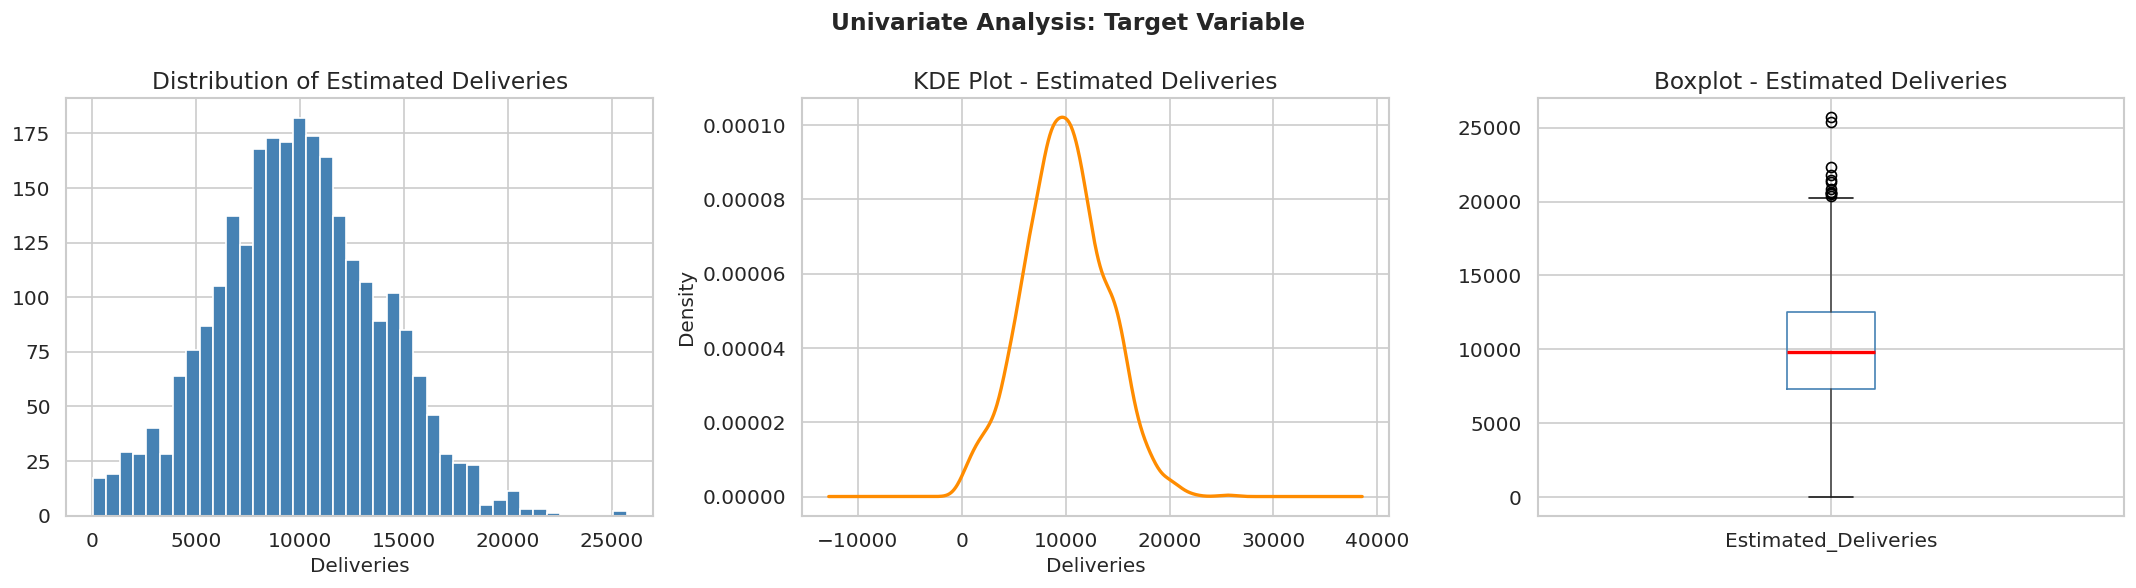

Mean: 9,922
Median: 9,857
Std Dev: 3,936


In [65]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# histogram
df['Estimated_Deliveries'].hist(bins=40, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Estimated Deliveries')
axes[0].set_xlabel('Deliveries')

df['Estimated_Deliveries'].plot(kind='kde', ax=axes[1], color='darkorange', linewidth=2)
axes[1].set_title('KDE Plot - Estimated Deliveries')
axes[1].set_xlabel('Deliveries')

df.boxplot(column='Estimated_Deliveries', ax=axes[2],
           boxprops=dict(color='steelblue'),
           medianprops=dict(color='red', linewidth=2))
axes[2].set_title('Boxplot - Estimated Deliveries')

plt.suptitle('Univariate Analysis: Target Variable', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print(f"Mean: {df['Estimated_Deliveries'].mean():,.0f}")
print(f"Median: {df['Estimated_Deliveries'].median():,.0f}")
print(f"Std Dev: {df['Estimated_Deliveries'].std():,.0f}")

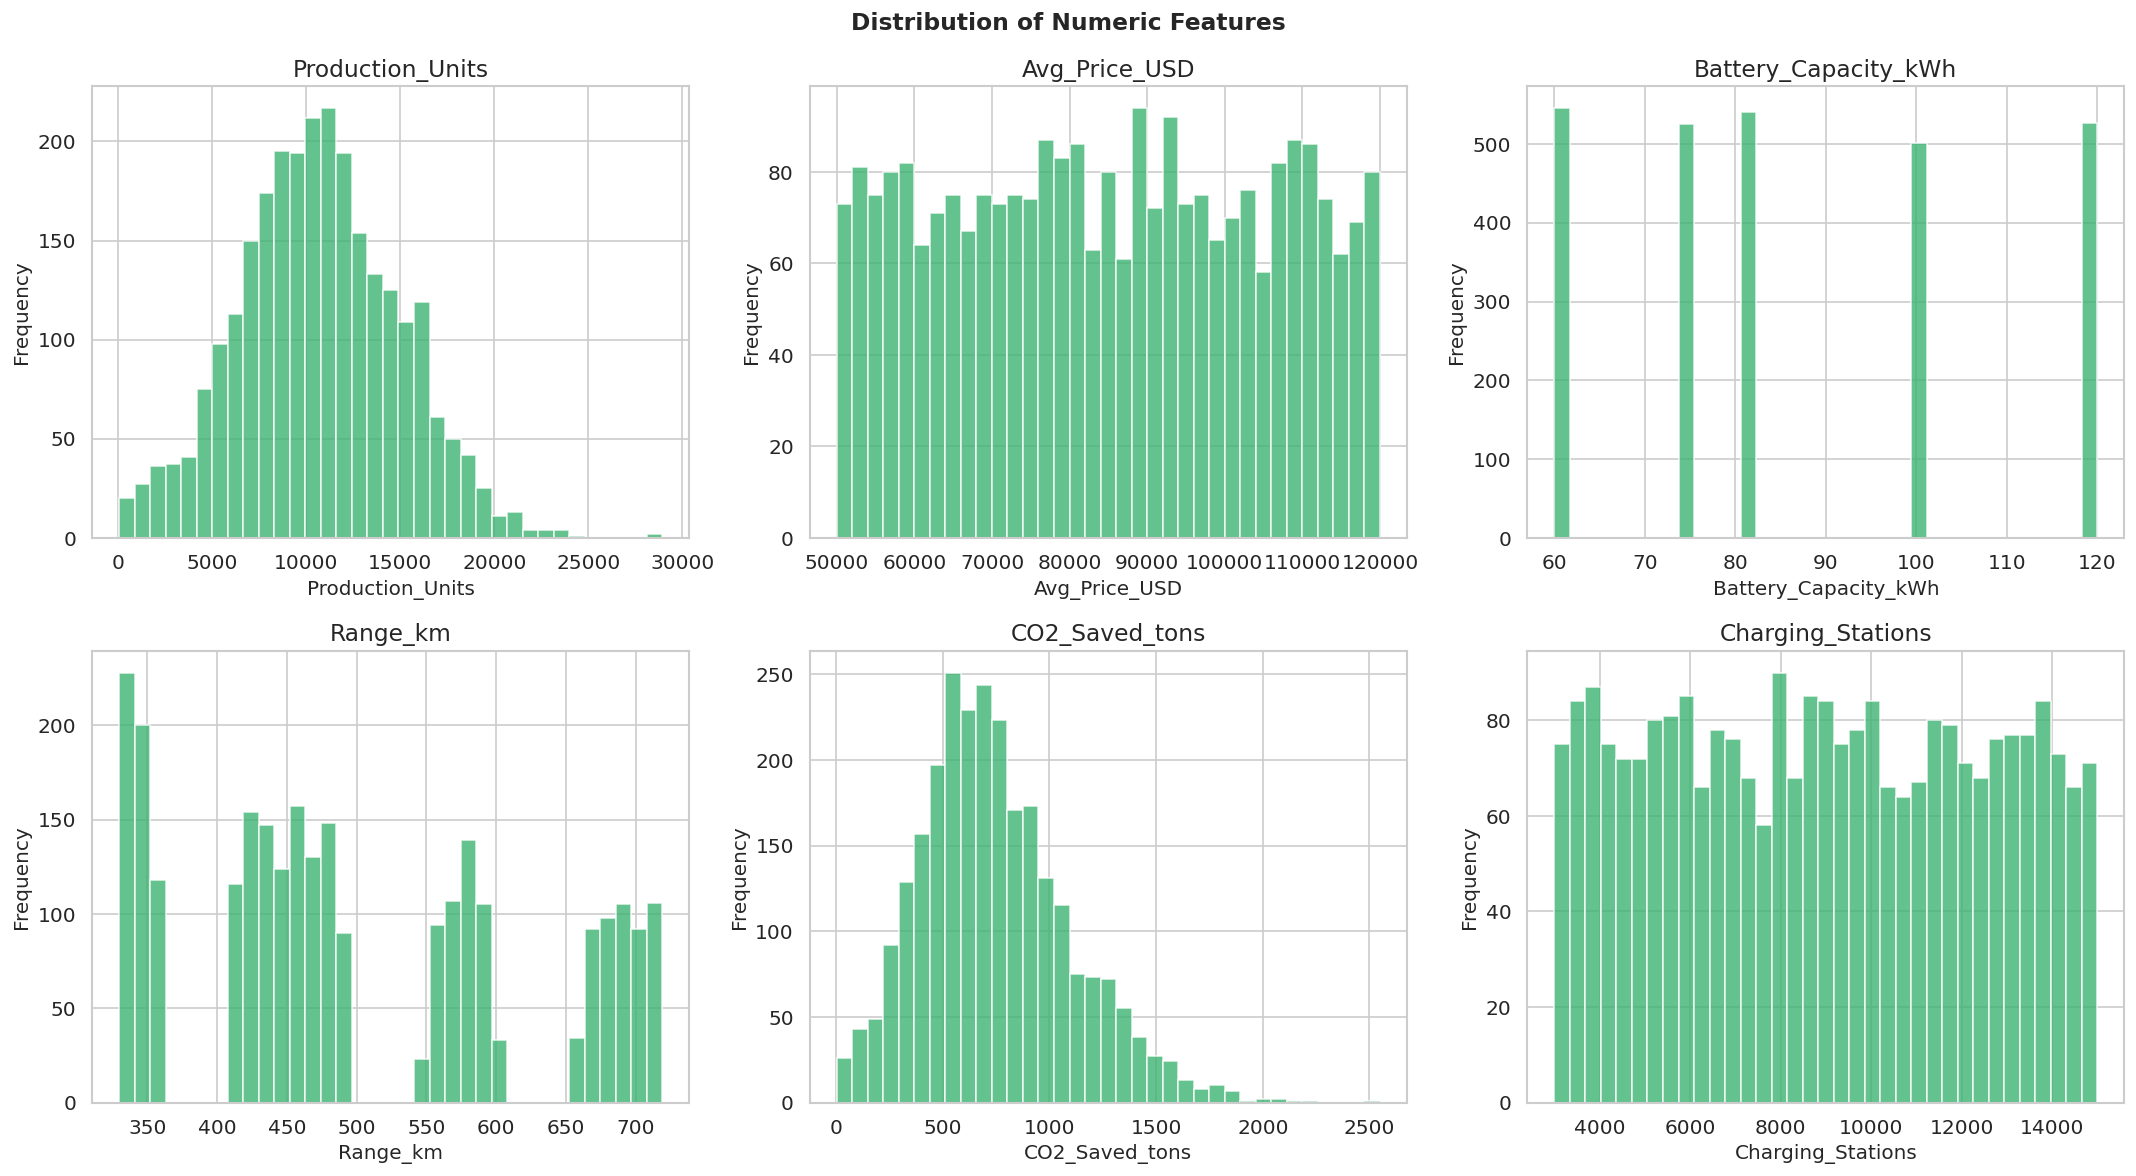

In [66]:
plot_cols = ['Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh',
             'Range_km', 'CO2_Saved_tons', 'Charging_Stations']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(plot_cols):
    axes[i].hist(df[col], bins=35, color='mediumseagreen', edgecolor='white', alpha=0.8)
    axes[i].set_title(f'{col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

plt.suptitle('Distribution of Numeric Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

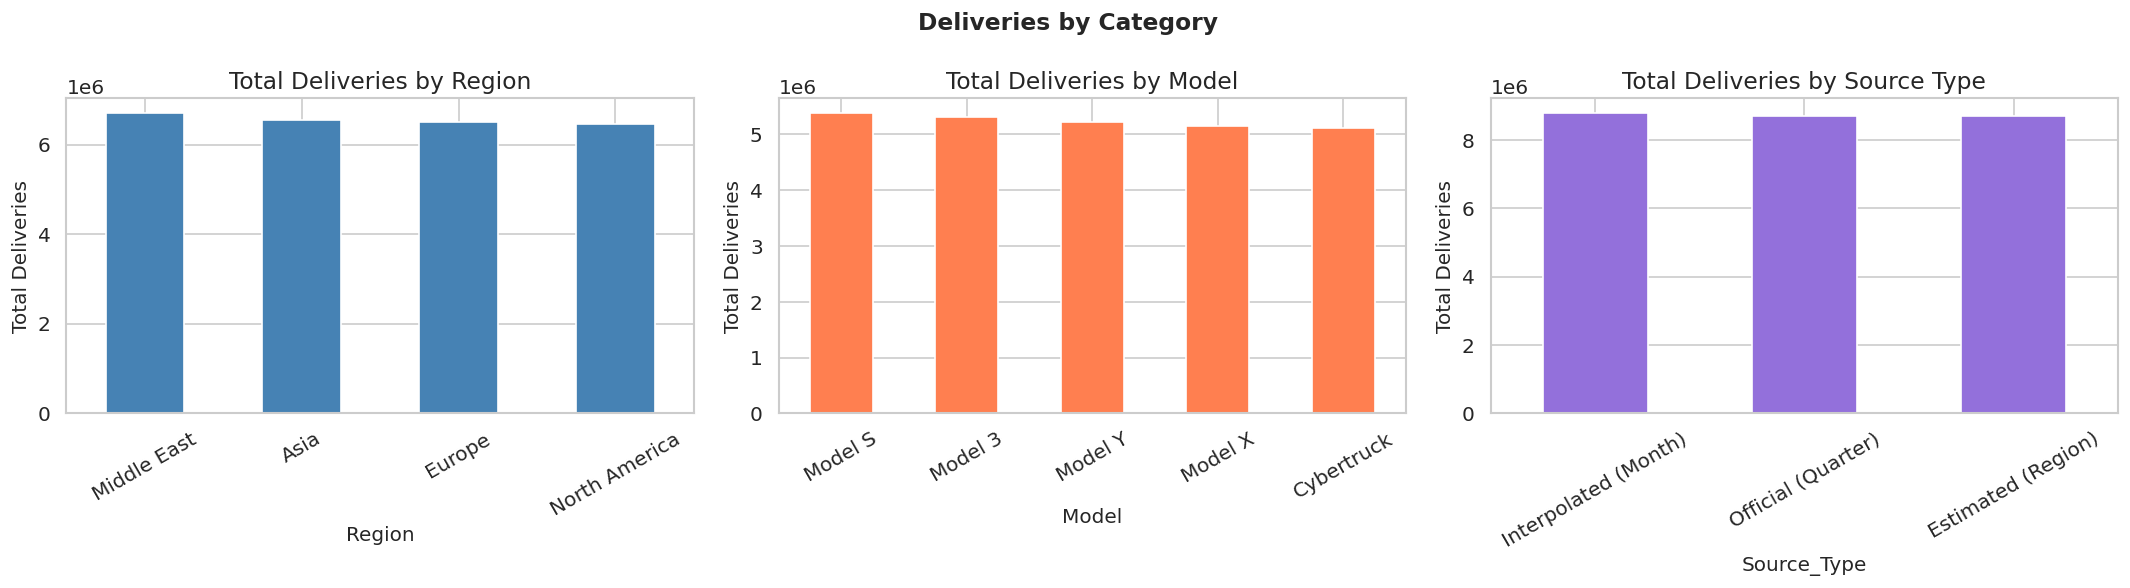

In [67]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

region_totals = df.groupby('Region')['Estimated_Deliveries'].sum().sort_values(ascending=False)
region_totals.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Total Deliveries by Region')
axes[0].set_ylabel('Total Deliveries')
axes[0].tick_params(axis='x', rotation=30)

model_totals = df.groupby('Model')['Estimated_Deliveries'].sum().sort_values(ascending=False)
model_totals.plot(kind='bar', ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('Total Deliveries by Model')
axes[1].set_ylabel('Total Deliveries')
axes[1].tick_params(axis='x', rotation=30)

source_totals = df.groupby('Source_Type')['Estimated_Deliveries'].sum().sort_values(ascending=False)
source_totals.plot(kind='bar', ax=axes[2], color='mediumpurple', edgecolor='white')
axes[2].set_title('Total Deliveries by Source Type')
axes[2].set_ylabel('Total Deliveries')
axes[2].tick_params(axis='x', rotation=30)

plt.suptitle('Deliveries by Category', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

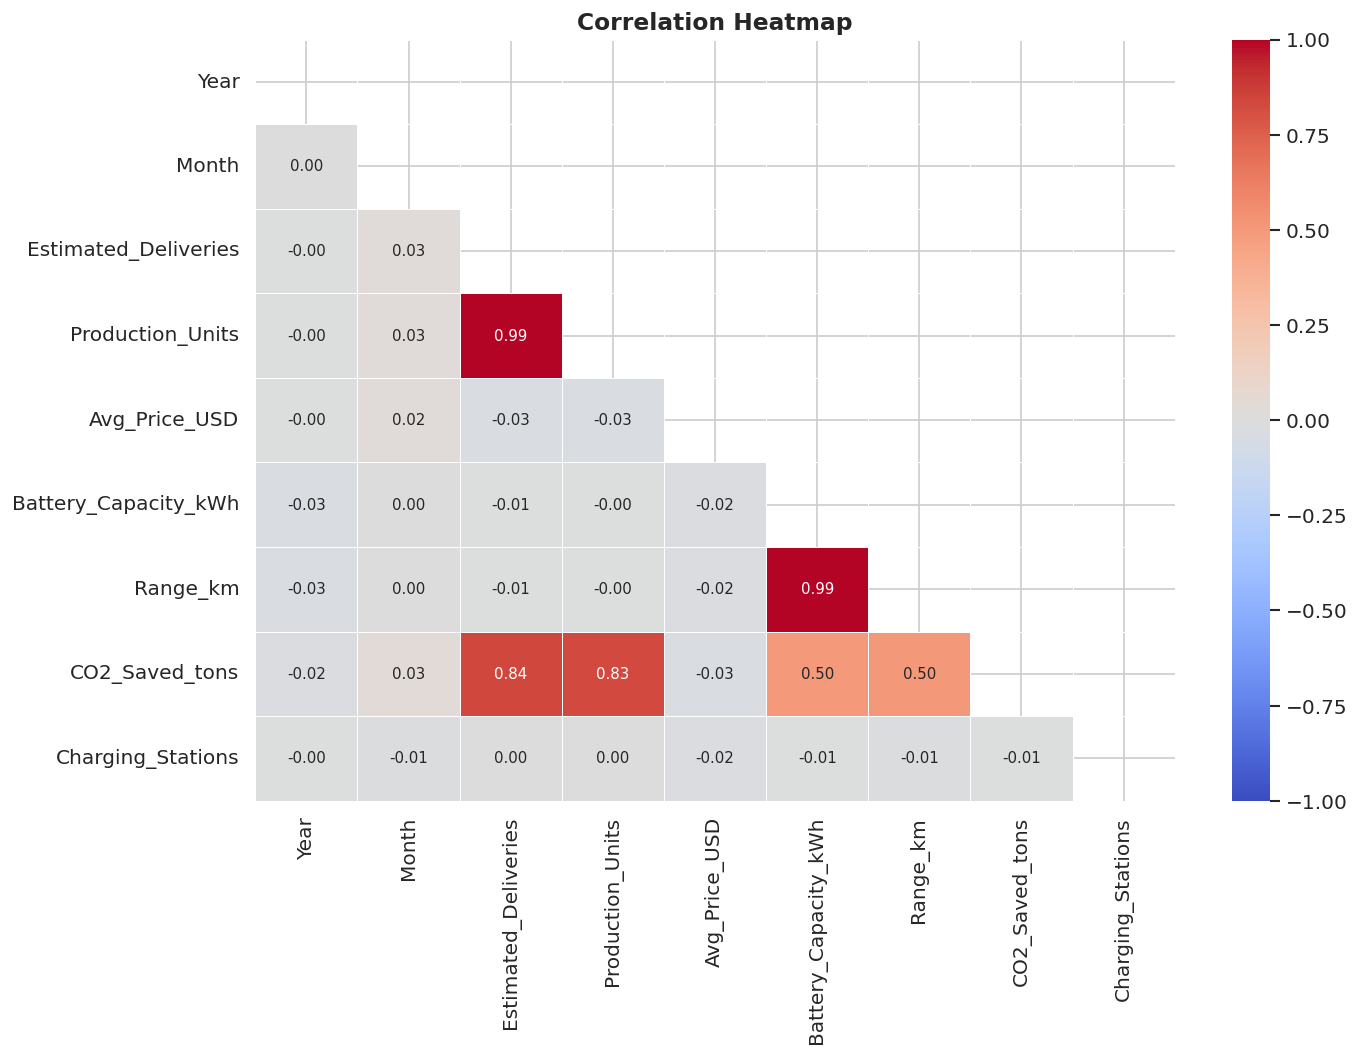

In [68]:
fig, ax = plt.subplots(figsize=(12, 9))
corr_matrix = df[numeric_cols].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', linewidths=0.5, ax=ax,
            vmin=-1, vmax=1, annot_kws={'size': 9})

ax.set_title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

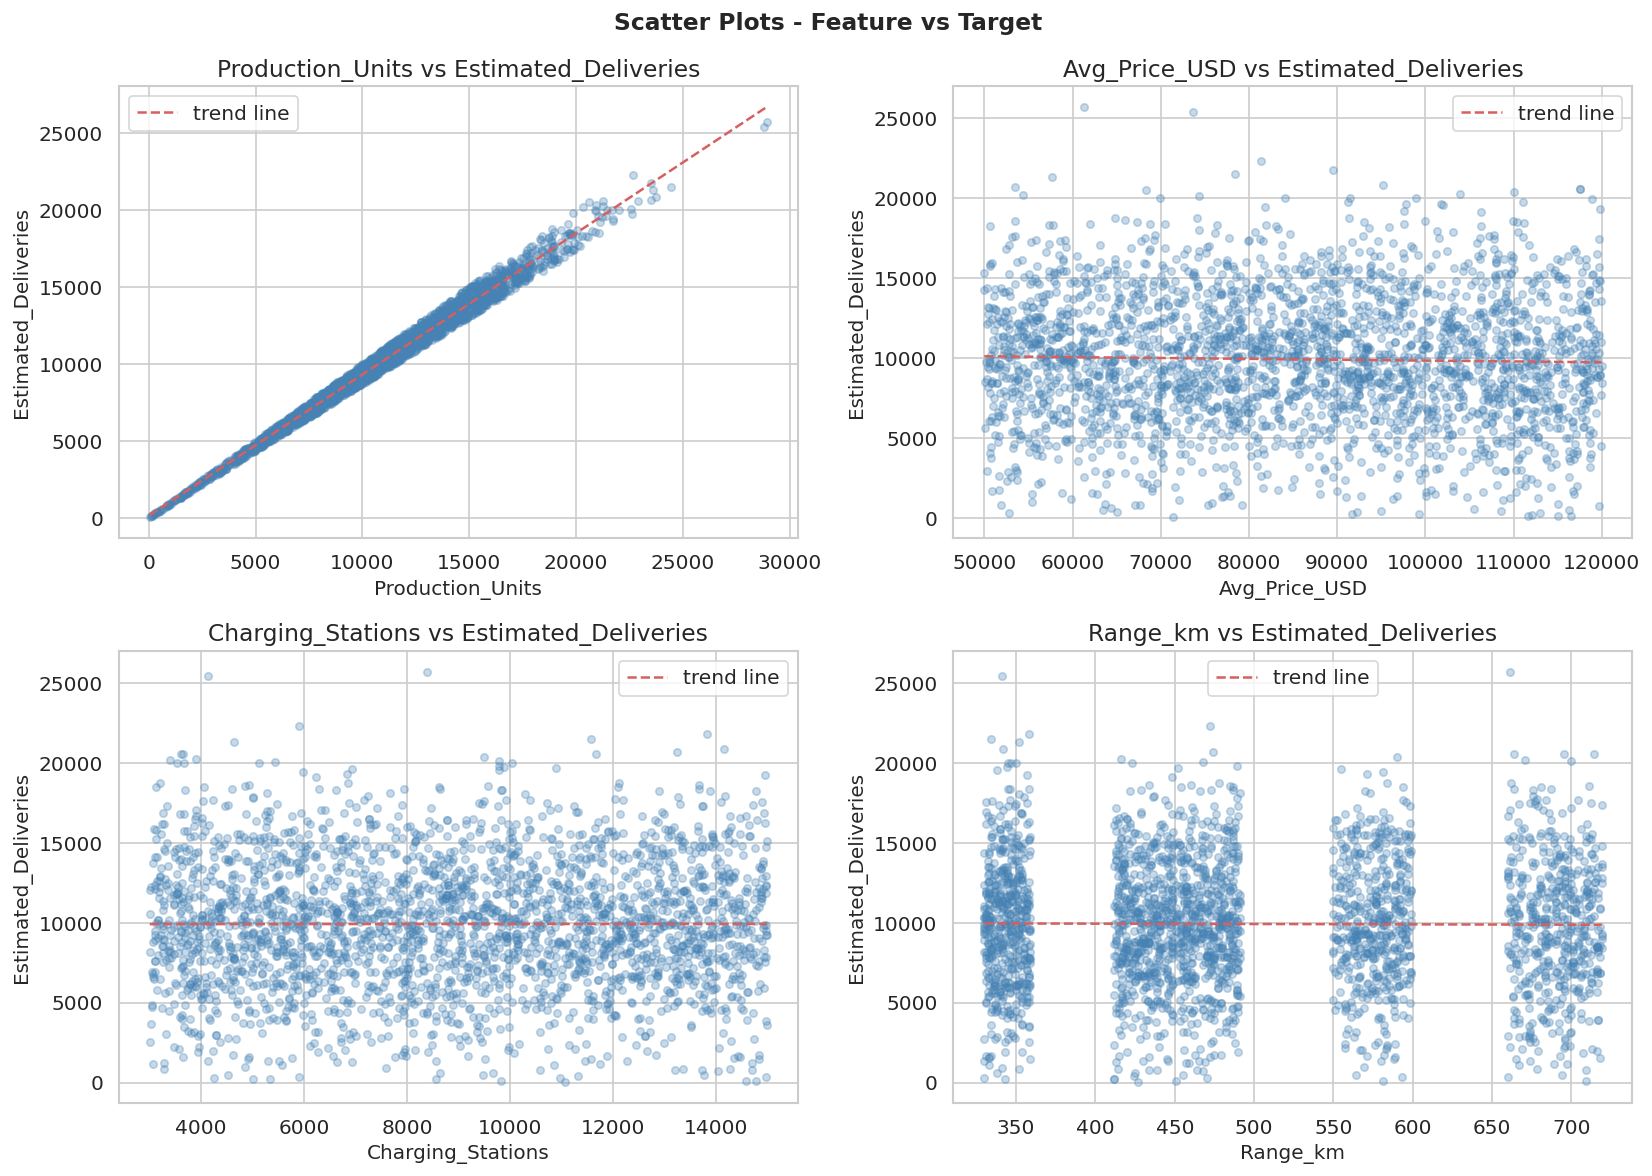

In [69]:
scatter_pairs = [
    ('Production_Units', 'Estimated_Deliveries'),
    ('Avg_Price_USD', 'Estimated_Deliveries'),
    ('Charging_Stations', 'Estimated_Deliveries'),
    ('Range_km', 'Estimated_Deliveries'),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, (x_col, y_col) in enumerate(scatter_pairs):
    axes[i].scatter(df[x_col], df[y_col], alpha=0.3, s=20, color='steelblue')
    
    # adding a trend line
    z = np.polyfit(df[x_col].dropna(), df[y_col].dropna(), 1)
    p = np.poly1d(z)
    x_line = np.linspace(df[x_col].min(), df[x_col].max(), 100)
    axes[i].plot(x_line, p(x_line), 'r--', linewidth=1.5, label='trend line')
    
    axes[i].set_xlabel(x_col)
    axes[i].set_ylabel(y_col)
    axes[i].set_title(f'{x_col} vs {y_col}')
    axes[i].legend()

plt.suptitle('Scatter Plots - Feature vs Target', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

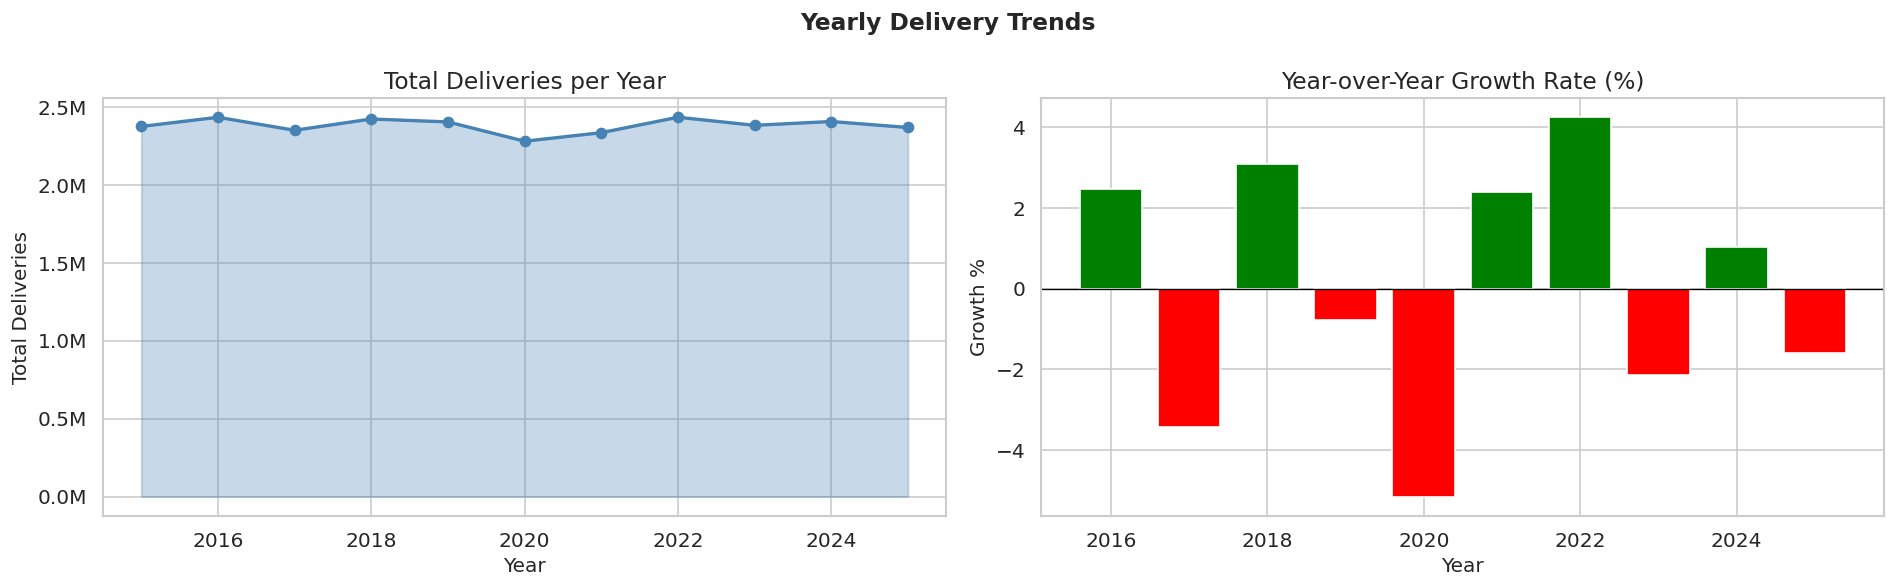

In [70]:
yearly = df.groupby('Year')['Estimated_Deliveries'].sum().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].fill_between(yearly['Year'], yearly['Estimated_Deliveries'], alpha=0.3, color='steelblue')
axes[0].plot(yearly['Year'], yearly['Estimated_Deliveries'], marker='o', color='steelblue', linewidth=2)
axes[0].set_title('Total Deliveries per Year')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Total Deliveries')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

yearly['YoY_Growth'] = yearly['Estimated_Deliveries'].pct_change() * 100
axes[1].bar(yearly['Year'][1:], yearly['YoY_Growth'][1:],
            color=['green' if v > 0 else 'red' for v in yearly['YoY_Growth'][1:]],
            edgecolor='white')
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title('Year-over-Year Growth Rate (%)')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Growth %')

plt.suptitle('Yearly Delivery Trends', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

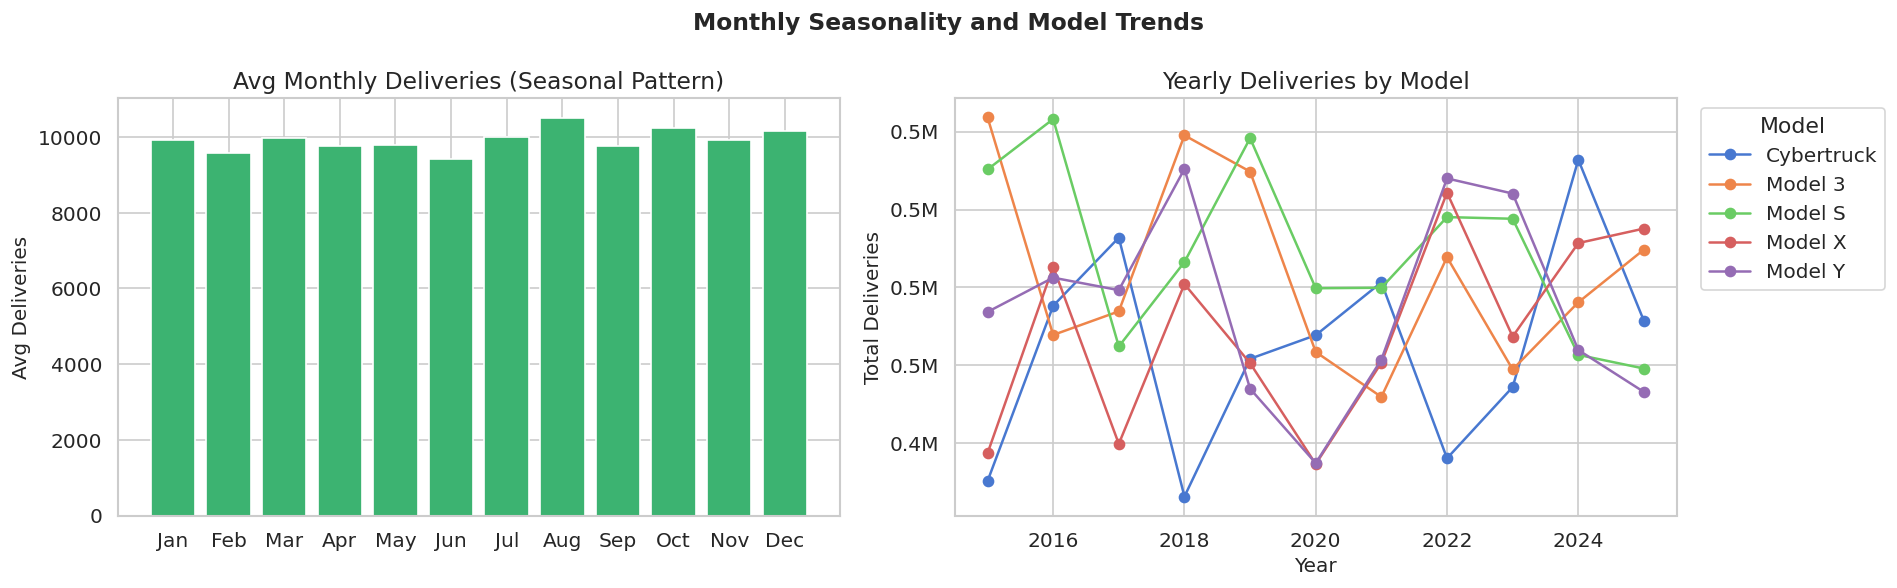

In [71]:
monthly_avg = df.groupby('Month')['Estimated_Deliveries'].mean().reset_index()
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].bar(monthly_avg['Month'], monthly_avg['Estimated_Deliveries'],
            color='mediumseagreen', edgecolor='white')
axes[0].set_xticks(range(1, 13))
axes[0].set_xticklabels(month_names)
axes[0].set_title('Avg Monthly Deliveries (Seasonal Pattern)')
axes[0].set_ylabel('Avg Deliveries')

model_year = df.groupby(['Year', 'Model'])['Estimated_Deliveries'].sum().unstack()
model_year.plot(ax=axes[1], marker='o', linewidth=1.5)
axes[1].set_title('Yearly Deliveries by Model')
axes[1].set_ylabel('Total Deliveries')
axes[1].legend(title='Model', bbox_to_anchor=(1.02, 1))
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

plt.suptitle('Monthly Seasonality and Model Trends', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

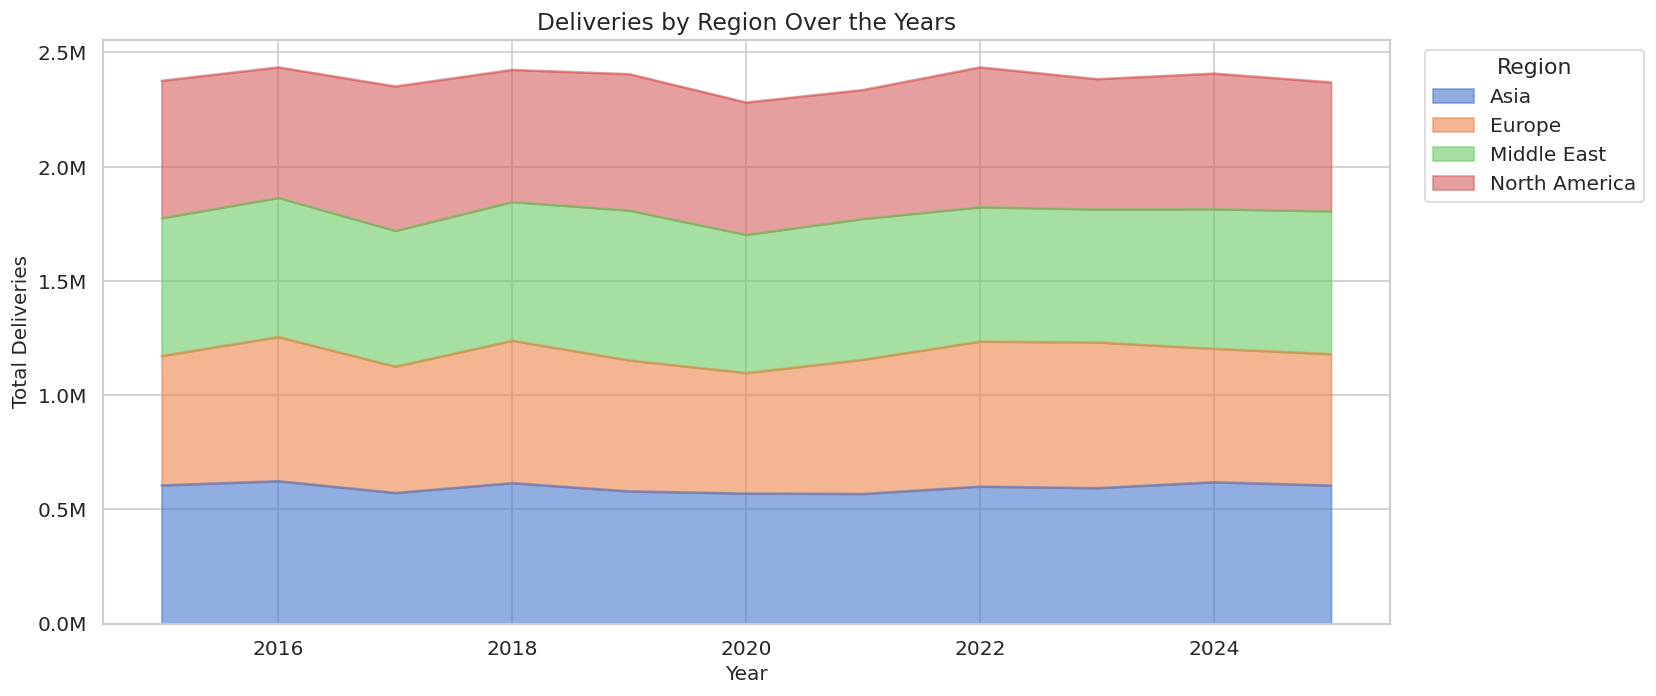

In [72]:
region_year = df.groupby(['Year', 'Region'])['Estimated_Deliveries'].sum().unstack()

fig, ax = plt.subplots(figsize=(14, 6))
region_year.plot(kind='area', ax=ax, alpha=0.6)
ax.set_title('Deliveries by Region Over the Years')
ax.set_ylabel('Total Deliveries')
ax.legend(title='Region', bbox_to_anchor=(1.02, 1))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
plt.tight_layout()
plt.show()

In [73]:
df_fe = df.copy()

df_fe['Quarter'] = df_fe['Date'].dt.quarter
df_fe['Week'] = df_fe['Date'].dt.isocalendar().week.astype(int)

df_fe['Is_Q4'] = (df_fe['Quarter'] == 4).astype(int)
df_fe['Is_Q3'] = (df_fe['Quarter'] == 3).astype(int)

print('new date features added:', ['Quarter', 'Week', 'Is_Q4', 'Is_Q3'])
df_fe[['Date', 'Quarter', 'Week', 'Is_Q4', 'Is_Q3']].head()

new date features added: ['Quarter', 'Week', 'Is_Q4', 'Is_Q3']


,Date,Quarter,Week,Is_Q4,Is_Q3
0,2023-05-01,2,18,0,0
1,2015-02-01,1,5,0,0
2,2019-01-01,1,1,0,0
3,2021-02-01,1,5,0,0
4,2016-12-01,4,48,1,0


In [74]:
monthly_global = df_fe.groupby(['Year', 'Month'])['Estimated_Deliveries'].sum().reset_index()
monthly_global = monthly_global.sort_values(['Year', 'Month']).reset_index(drop=True)
monthly_global['Date'] = pd.to_datetime(monthly_global[['Year', 'Month']].assign(day=1))

monthly_global['Lag1'] = monthly_global['Estimated_Deliveries'].shift(1)
monthly_global['Lag2'] = monthly_global['Estimated_Deliveries'].shift(2)
monthly_global['Lag3'] = monthly_global['Estimated_Deliveries'].shift(3)

monthly_global['Rolling_Mean_3'] = monthly_global['Estimated_Deliveries'].rolling(3).mean()
monthly_global['Rolling_Std_3'] = monthly_global['Estimated_Deliveries'].rolling(3).std()
monthly_global['Rolling_Mean_6'] = monthly_global['Estimated_Deliveries'].rolling(6).mean()

monthly_global['MoM_Growth'] = monthly_global['Estimated_Deliveries'].pct_change() * 100
monthly_global['YoY_Growth'] = monthly_global['Estimated_Deliveries'].pct_change(12) * 100

print(f'monthly time series shape: {monthly_global.shape}')
monthly_global.tail(6)

monthly time series shape: (132, 12)


,Year,Month,Estimated_Deliveries,Date,Lag1,Lag2,Lag3,Rolling_Mean_3,Rolling_Std_3,Rolling_Mean_6,MoM_Growth,YoY_Growth
126,2025,7,201390,2025-07-01,199951.0,172377.0,209709.0,191239.333333,16351.097649,198476.000000,0.719676,3.675676
127,2025,8,214357,2025-08-01,201390.0,199951.0,172377.0,205232.666667,7934.593520,201692.000000,6.438751,4.340440
128,2025,9,193337,2025-09-01,214357.0,201390.0,199951.0,203028.000000,10605.299760,198520.166667,-9.806071,-1.342566
129,2025,10,178964,2025-10-01,193337.0,214357.0,201390.0,195552.666667,17800.224615,193396.000000,-7.434169,-7.415493
130,2025,11,197146,2025-11-01,178964.0,193337.0,214357.0,189815.666667,9588.854068,197524.166667,10.159585,-2.948763
131,2025,12,209391,2025-12-01,197146.0,178964.0,193337.0,195167.000000,15309.732623,199097.500000,6.211133,4.367785


In [75]:
df_model = df_fe.copy()

le_region = LabelEncoder()
le_model_enc = LabelEncoder()
le_source = LabelEncoder()

df_model['Region_enc'] = le_region.fit_transform(df_model['Region'])
df_model['Model_enc'] = le_model_enc.fit_transform(df_model['Model'])
df_model['Source_Type_enc'] = le_source.fit_transform(df_model['Source_Type'])

print('encoding done!')
print('Region mapping:', dict(zip(le_region.classes_, le_region.transform(le_region.classes_))))
print('Model mapping:', dict(zip(le_model_enc.classes_, le_model_enc.transform(le_model_enc.classes_))))

encoding done!
Region mapping: {'Asia': np.int64(0), 'Europe': np.int64(1), 'Middle East': np.int64(2), 'North America': np.int64(3)}
Model mapping: {'Cybertruck': np.int64(0), 'Model 3': np.int64(1), 'Model S': np.int64(2), 'Model X': np.int64(3), 'Model Y': np.int64(4)}


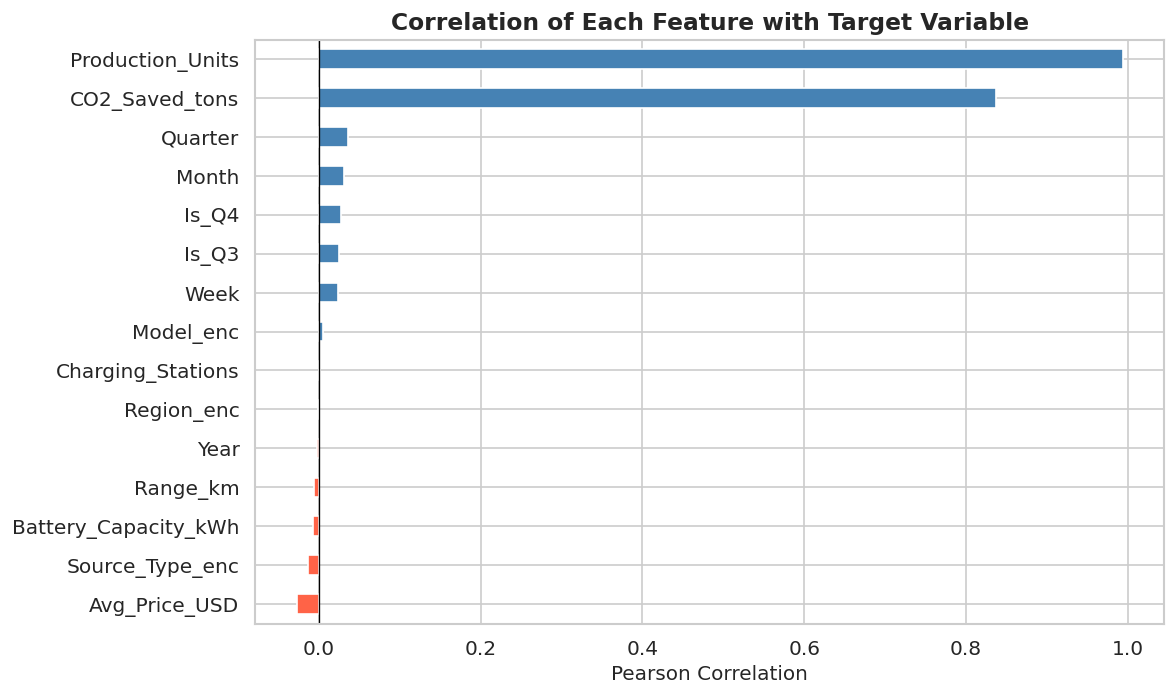

In [76]:
feature_cols = ['Year', 'Month', 'Quarter', 'Is_Q4', 'Is_Q3', 'Week',
                'Region_enc', 'Model_enc', 'Source_Type_enc',
                'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh',
                'Range_km', 'CO2_Saved_tons', 'Charging_Stations']

TARGET = 'Estimated_Deliveries'

corr_with_target = df_model[feature_cols + [TARGET]].corr()[TARGET].drop(TARGET).sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['tomato' if v < 0 else 'steelblue' for v in corr_with_target]
corr_with_target.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Correlation of Each Feature with Target Variable', fontweight='bold')
ax.set_xlabel('Pearson Correlation')
plt.tight_layout()
plt.show()

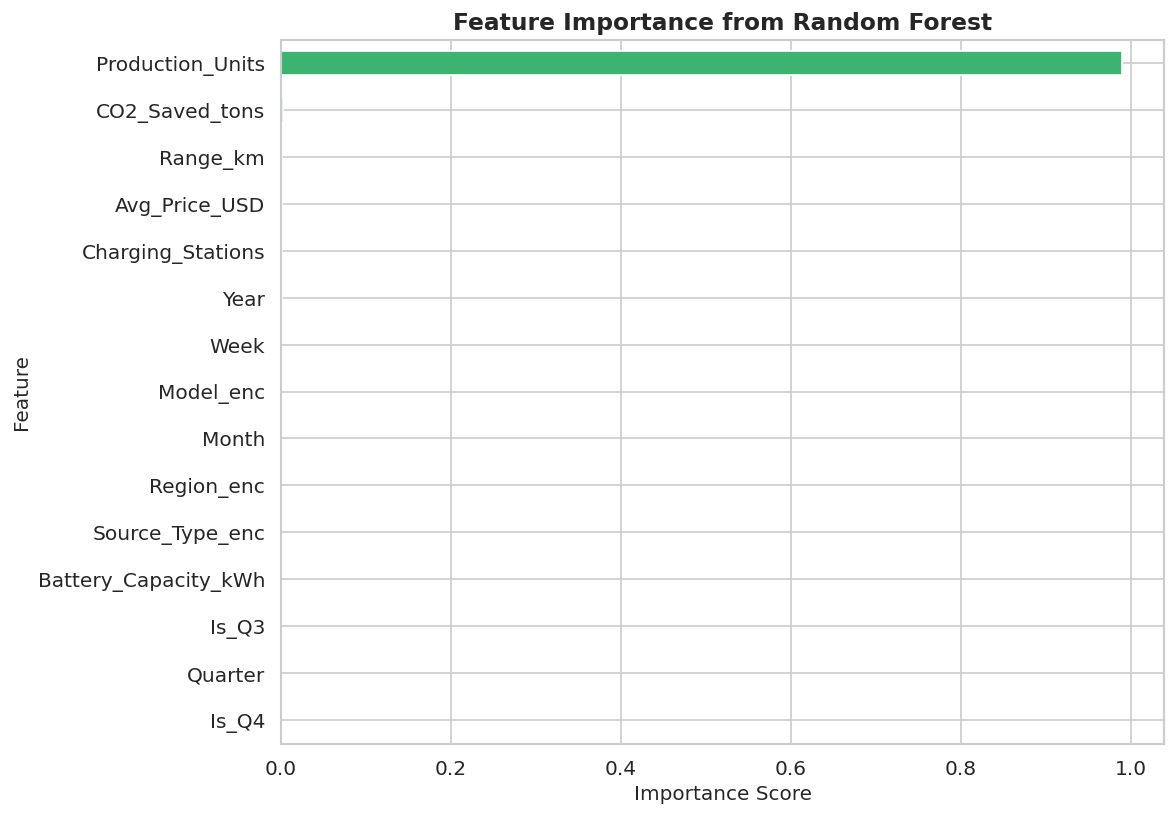


Top 5 most important features:
          Feature  Importance
Charging_Stations    0.001102
    Avg_Price_USD    0.001246
         Range_km    0.001512
   CO2_Saved_tons    0.002563
 Production_Units    0.990413


In [77]:
X_imp = df_model[feature_cols].fillna(df_model[feature_cols].median())
y_imp = df_model[TARGET]

rf_for_importance = RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)
rf_for_importance.fit(X_imp, y_imp)

importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': rf_for_importance.feature_importances_
}).sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
importance_df.plot(kind='barh', x='Feature', y='Importance',
                   ax=ax, color='mediumseagreen', edgecolor='white', legend=False)
ax.set_title('Feature Importance from Random Forest', fontsize=14, fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.show()

print('\nTop 5 most important features:')
print(importance_df.tail(5).to_string(index=False))

In [78]:
X = df_model[feature_cols].fillna(df_model[feature_cols].median())
y = df_model[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE
)

print(f'Training samples: {X_train.shape[0]}')
print(f'Testing samples: {X_test.shape[0]}')

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)  # only transform test, don't fit again

Training samples: 2112
Testing samples: 528


In [79]:
def train_and_evaluate(name, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    preds = model.predict(X_te)
    
    mae = mean_absolute_error(y_te, preds)
    rmse = np.sqrt(mean_squared_error(y_te, preds))
    r2 = r2_score(y_te, preds)
    
    cv_r2 = cross_val_score(model, X_tr, y_tr, cv=5, scoring='r2').mean()
    
    return {
        'Model': name,
        'MAE': round(mae, 2),
        'RMSE': round(rmse, 2),
        'R2': round(r2, 4),
        'CV_R2': round(cv_r2, 4),
        '_preds': preds
    }

lr_model = LinearRegression()
res_lr = train_and_evaluate('Linear Regression', lr_model,
                             X_train_sc, y_train, X_test_sc, y_test)

rf_model = RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
res_rf = train_and_evaluate('Random Forest', rf_model, X_train, y_train, X_test, y_test)

gb_model = GradientBoostingRegressor(n_estimators=200, random_state=RANDOM_STATE)
res_gb = train_and_evaluate('Gradient Boosting', gb_model, X_train, y_train, X_test, y_test)

results = []
for r in [res_lr, res_rf, res_gb]:
    results.append({k: v for k, v in r.items() if k != '_preds'})

results_df = pd.DataFrame(results).set_index('Model')
print('Model Comparison:')
print('='*50)
print(results_df.to_string())
print('='*50)

Model Comparison:
                      MAE    RMSE      R2   CV_R2
Model                                            
Linear Regression  310.22  383.68  0.9901  0.9902
Random Forest      323.38  409.09  0.9888  0.9886
Gradient Boosting  302.54  375.48  0.9905  0.9908


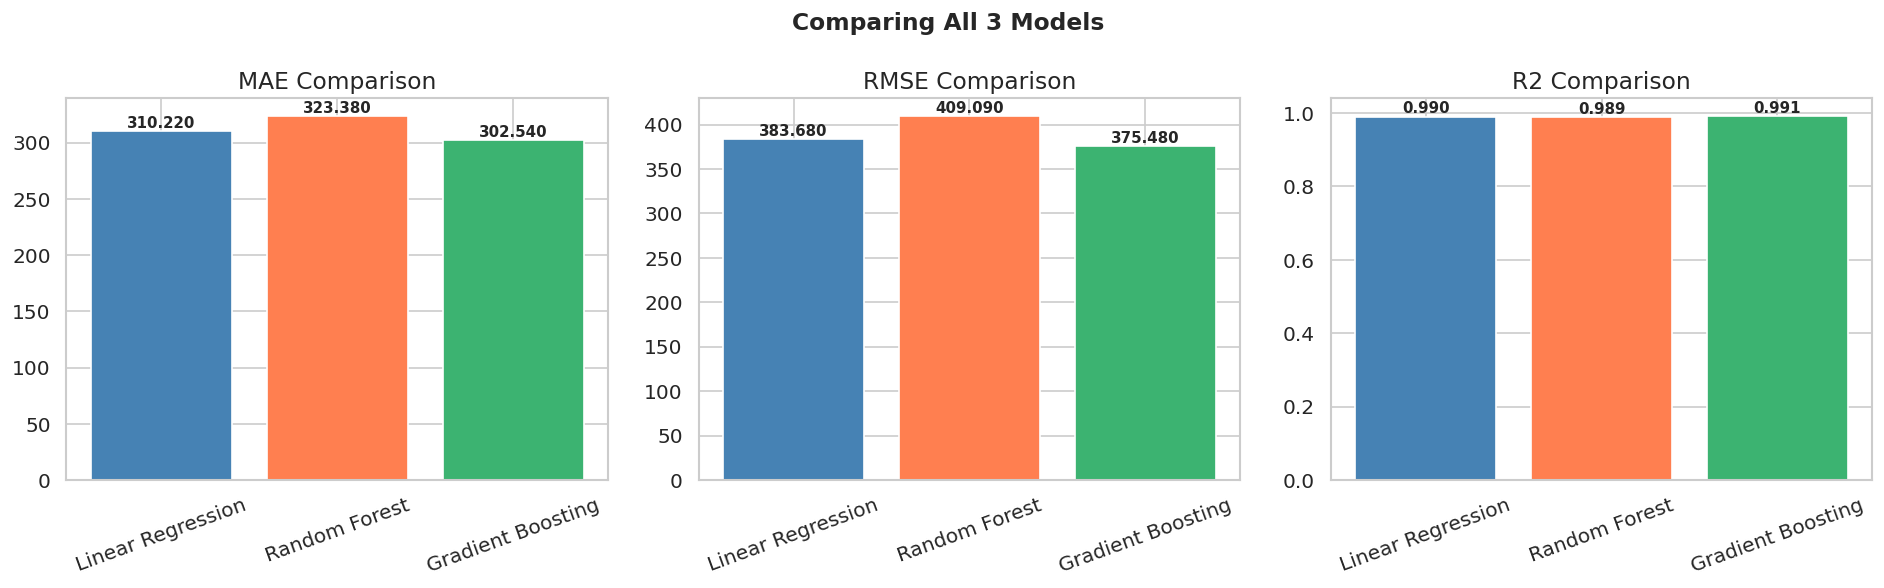

In [80]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metrics = ['MAE', 'RMSE', 'R2']
colors = ['steelblue', 'coral', 'mediumseagreen']

for i, metric in enumerate(metrics):
    vals = results_df[metric]
    axes[i].bar(vals.index, vals, color=colors, edgecolor='white')
    axes[i].set_title(f'{metric} Comparison')
    axes[i].tick_params(axis='x', rotation=20)
    # adding value labels on top of bars
    for bar, val in zip(axes[i].patches, vals):
        axes[i].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() * 1.01,
                     f'{val:.3f}', ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Comparing All 3 Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [81]:
rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

print('running GridSearchCV for Random Forest... this may take a minute')
rf_grid = GridSearchCV(
    RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
    rf_params,
    cv=3,
    scoring='r2',
    n_jobs=-1
)
rf_grid.fit(X_train, y_train)

print(f'best parameters: {rf_grid.best_params_}')
print(f'best CV R2 score: {rf_grid.best_score_:.4f}')

running GridSearchCV for Random Forest... this may take a minute
best parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
best CV R2 score: 0.9880


In [82]:
gb_params = {
    'learning_rate': [0.05, 0.1],
    'n_estimators': [100, 200],
    'max_depth': [3, 5]
}

print('running GridSearchCV for Gradient Boosting...')
gb_grid = GridSearchCV(
    GradientBoostingRegressor(random_state=RANDOM_STATE),
    gb_params,
    cv=3,
    scoring='r2',
    n_jobs=-1
)
gb_grid.fit(X_train, y_train)

print(f'best parameters: {gb_grid.best_params_}')
print(f'best CV R2 score: {gb_grid.best_score_:.4f}')

running GridSearchCV for Gradient Boosting...
best parameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}
best CV R2 score: 0.9916


In [83]:
best_rf = rf_grid.best_estimator_
best_gb = gb_grid.best_estimator_

rf_preds_tuned = best_rf.predict(X_test)
gb_preds_tuned = best_gb.predict(X_test)

print('After tuning:')
print(f'  Random Forest  -> R2={r2_score(y_test, rf_preds_tuned):.4f}, RMSE={np.sqrt(mean_squared_error(y_test, rf_preds_tuned)):.2f}')
print(f'  Grad Boosting  -> R2={r2_score(y_test, gb_preds_tuned):.4f}, RMSE={np.sqrt(mean_squared_error(y_test, gb_preds_tuned)):.2f}')

if r2_score(y_test, rf_preds_tuned) >= r2_score(y_test, gb_preds_tuned):
    champion_model = best_rf
    champion_preds = rf_preds_tuned
    champion_name = 'Tuned Random Forest'
else:
    champion_model = best_gb
    champion_preds = gb_preds_tuned
    champion_name = 'Tuned Gradient Boosting'

print(f'\nbest model: {champion_name}')

After tuning:
  Random Forest  -> R2=0.9887, RMSE=411.15
  Grad Boosting  -> R2=0.9931, RMSE=320.79

best model: Tuned Gradient Boosting


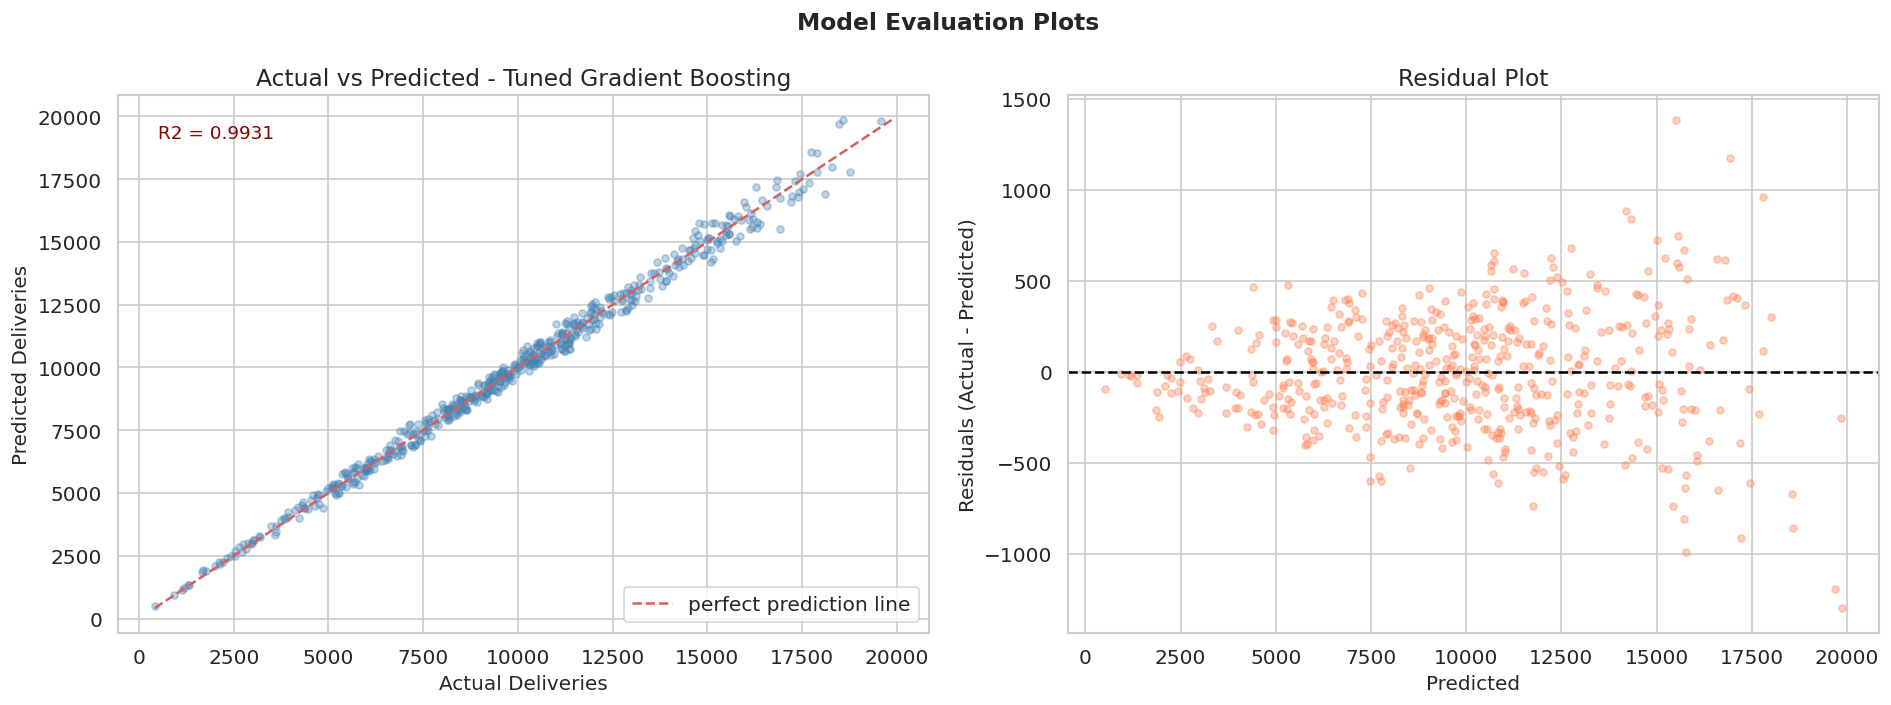

In [84]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].scatter(y_test, champion_preds, alpha=0.35, s=18, color='steelblue')
min_val = min(y_test.min(), champion_preds.min())
max_val = max(y_test.max(), champion_preds.max())
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=1.5, label='perfect prediction line')
axes[0].set_xlabel('Actual Deliveries')
axes[0].set_ylabel('Predicted Deliveries')
axes[0].set_title(f'Actual vs Predicted - {champion_name}')
axes[0].legend()
axes[0].text(0.05, 0.92, f'R2 = {r2_score(y_test, champion_preds):.4f}',
             transform=axes[0].transAxes, fontsize=11, color='darkred')

residuals = y_test.values - champion_preds
axes[1].scatter(champion_preds, residuals, alpha=0.35, s=18, color='coral')
axes[1].axhline(0, color='black', linewidth=1.5, linestyle='--')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Residuals (Actual - Predicted)')
axes[1].set_title('Residual Plot')

plt.suptitle('Model Evaluation Plots', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

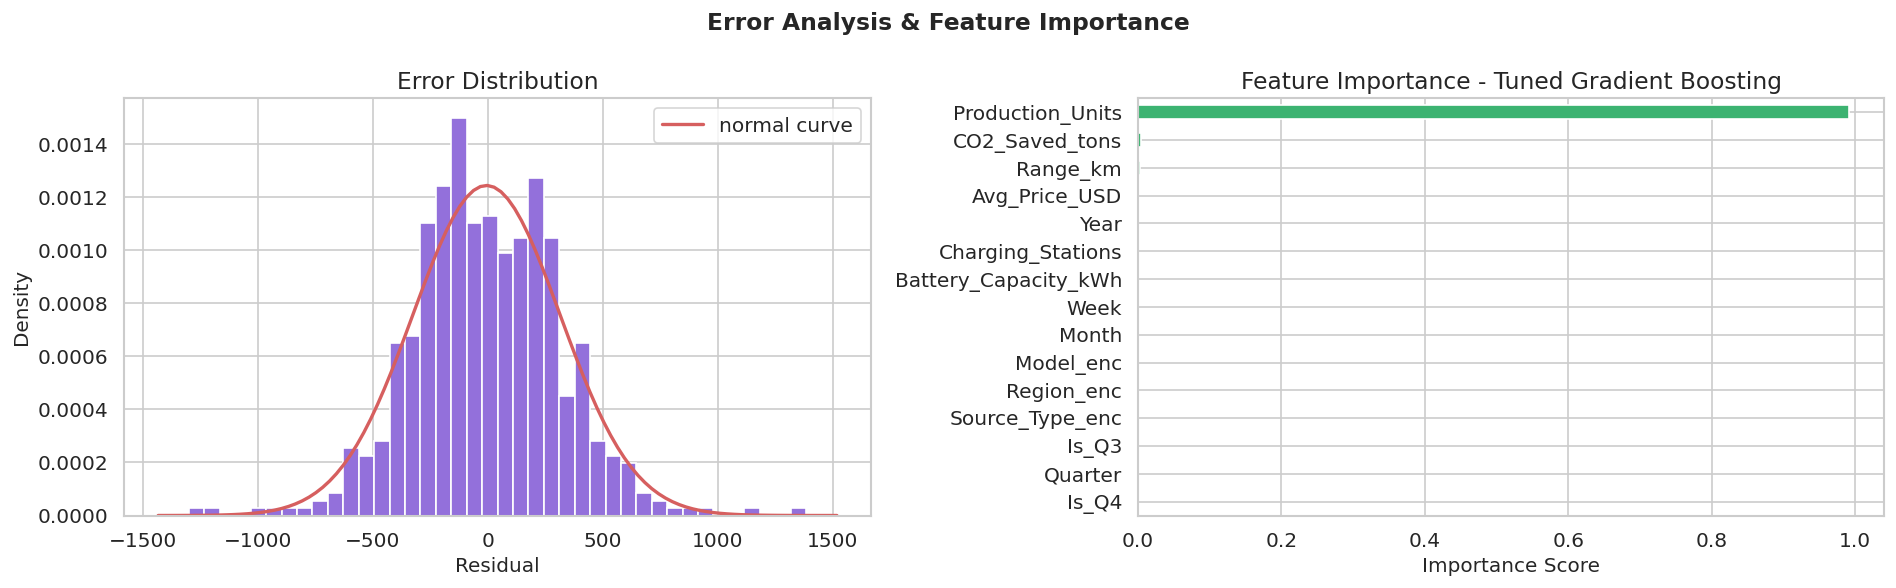

In [85]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].hist(residuals, bins=40, color='mediumpurple', edgecolor='white', density=True)
from scipy.stats import norm
xmin, xmax = axes[0].get_xlim()
x = np.linspace(xmin, xmax, 100)
# overlaying a normal curve to see if errors are normally distributed
axes[0].plot(x, norm.pdf(x, residuals.mean(), residuals.std()), 'r-', linewidth=2, label='normal curve')
axes[0].set_title('Error Distribution')
axes[0].set_xlabel('Residual')
axes[0].set_ylabel('Density')
axes[0].legend()

if hasattr(champion_model, 'feature_importances_'):
    imp = pd.Series(champion_model.feature_importances_, index=feature_cols)
    imp.sort_values().plot(kind='barh', ax=axes[1], color='mediumseagreen', edgecolor='white')
    axes[1].set_title(f'Feature Importance - {champion_name}')
    axes[1].set_xlabel('Importance Score')

plt.suptitle('Error Analysis & Feature Importance', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

number of months in data: 132
from 2015-01-01 to 2025-12-01


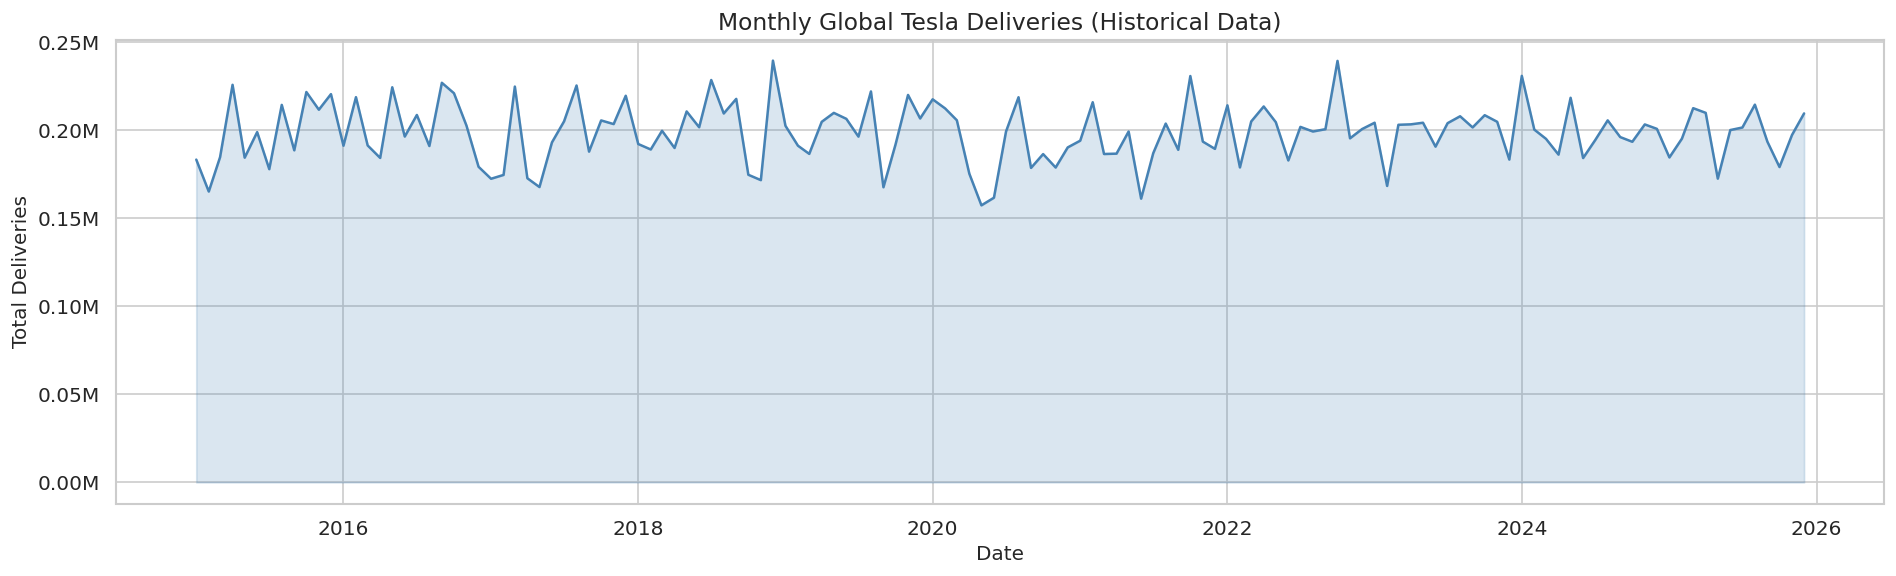

In [86]:
ts = df.groupby('Date')['Estimated_Deliveries'].sum().reset_index()
ts = ts.rename(columns={'Date': 'ds', 'Estimated_Deliveries': 'y'})  # prophet needs 'ds' and 'y' columns
ts = ts.sort_values('ds').reset_index(drop=True)

print(f'number of months in data: {len(ts)}')
print(f'from {ts["ds"].min().date()} to {ts["ds"].max().date()}')

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(ts['ds'], ts['y'], color='steelblue', linewidth=1.5)
ax.fill_between(ts['ds'], ts['y'], alpha=0.2, color='steelblue')
ax.set_title('Monthly Global Tesla Deliveries (Historical Data)')
ax.set_ylabel('Total Deliveries')
ax.set_xlabel('Date')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.2f}M'))
plt.tight_layout()
plt.show()

In [87]:
try:
    from prophet import Prophet
    USE_PROPHET = True
    print('Prophet is available, using it for forecasting')
except ImportError:
    USE_PROPHET = False
    print('Prophet not found, will use ARIMA as backup')

Prophet is available, using it for forecasting


20:43:26 - cmdstanpy - INFO - Chain [1] start processing
20:43:26 - cmdstanpy - INFO - Chain [1] done processing


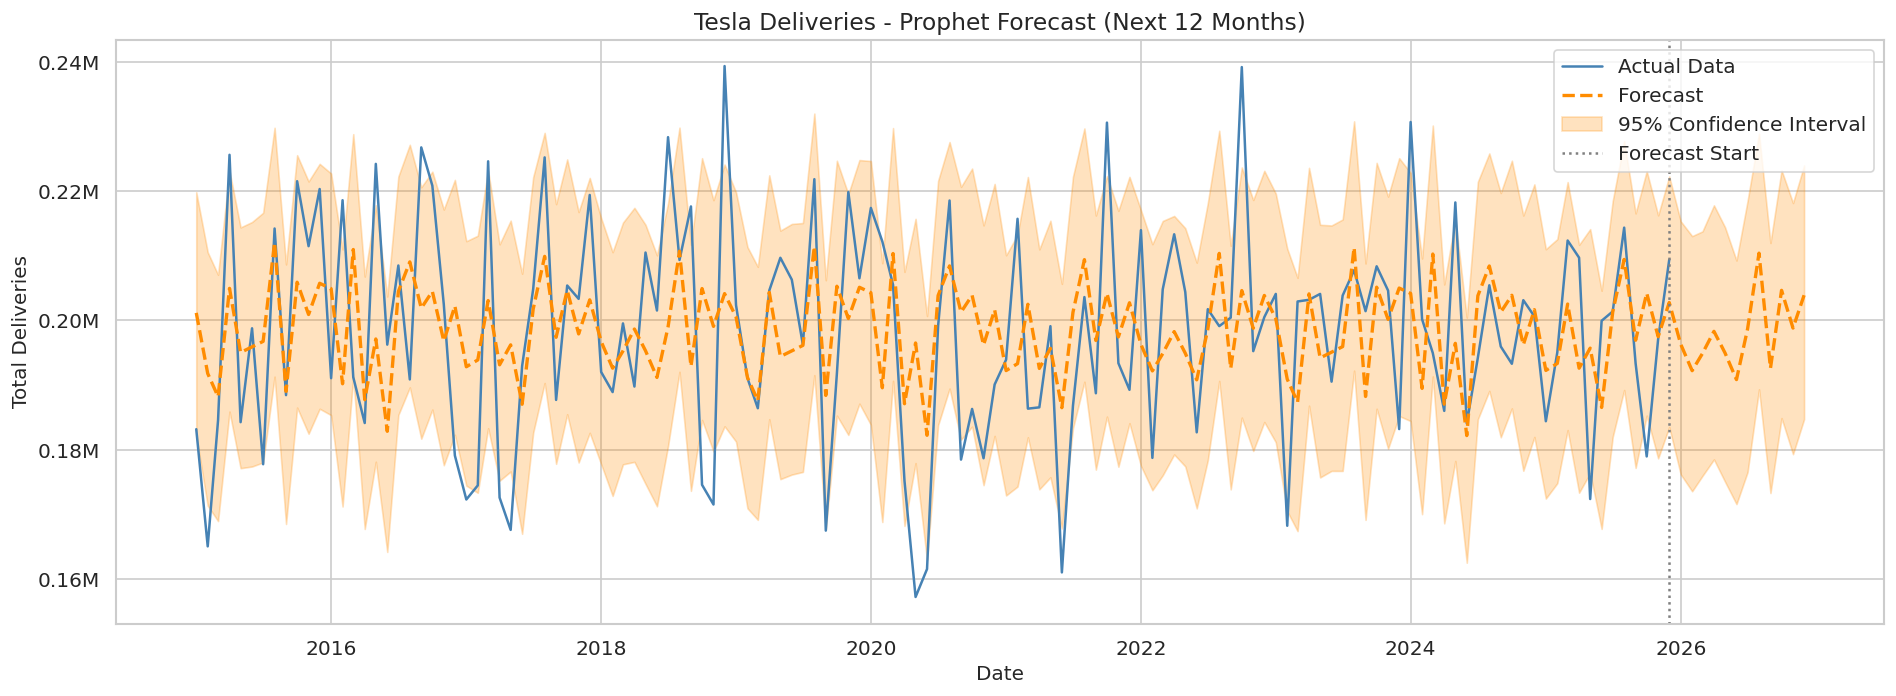


Forecast for next 12 months:
   Month  Forecast    Lower    Upper
Jan 2026  196333.0 176196.0 215345.0
Feb 2026  192229.0 173577.0 213045.0
Mar 2026  194905.0 175960.0 213782.0
Apr 2026  198318.0 178499.0 217803.0
May 2026  194974.0 175054.0 214418.0
Jun 2026  190853.0 171593.0 209272.0
Jul 2026  198678.0 176539.0 218470.0
Aug 2026  210413.0 189347.0 228888.0
Sep 2026  192603.0 173301.0 211979.0
Oct 2026  204658.0 184896.0 223228.0
Nov 2026  198821.0 179314.0 218165.0
Dec 2026  203903.0 184728.0 223982.0


In [88]:
if USE_PROPHET:
    m = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=False,
        daily_seasonality=False,
        changepoint_prior_scale=0.1,   # controls flexibility of trend
        seasonality_prior_scale=10
    )
    m.fit(ts)
    
    future = m.make_future_dataframe(periods=12, freq='MS')
    forecast = m.predict(future)
    
    fig, ax = plt.subplots(figsize=(16, 6))
    ax.plot(ts['ds'], ts['y'], color='steelblue', linewidth=1.5, label='Actual Data')
    ax.plot(forecast['ds'], forecast['yhat'],
            color='darkorange', linewidth=2, linestyle='--', label='Forecast')
    ax.fill_between(forecast['ds'], forecast['yhat_lower'], forecast['yhat_upper'],
                    alpha=0.25, color='darkorange', label='95% Confidence Interval')
    ax.axvline(ts['ds'].max(), color='gray', linestyle=':', linewidth=1.5, label='Forecast Start')
    ax.set_title('Tesla Deliveries - Prophet Forecast (Next 12 Months)')
    ax.set_ylabel('Total Deliveries')
    ax.set_xlabel('Date')
    ax.legend()
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.2f}M'))
    plt.tight_layout()
    plt.show()
    forecast_table = forecast[forecast['ds'] > ts['ds'].max()][['ds', 'yhat', 'yhat_lower', 'yhat_upper']]
    forecast_table.columns = ['Month', 'Forecast', 'Lower', 'Upper']
    forecast_table['Month'] = forecast_table['Month'].dt.strftime('%b %Y')
    forecast_table = forecast_table.round(0).reset_index(drop=True)
    print('\nForecast for next 12 months:')
    print(forecast_table.to_string(index=False))

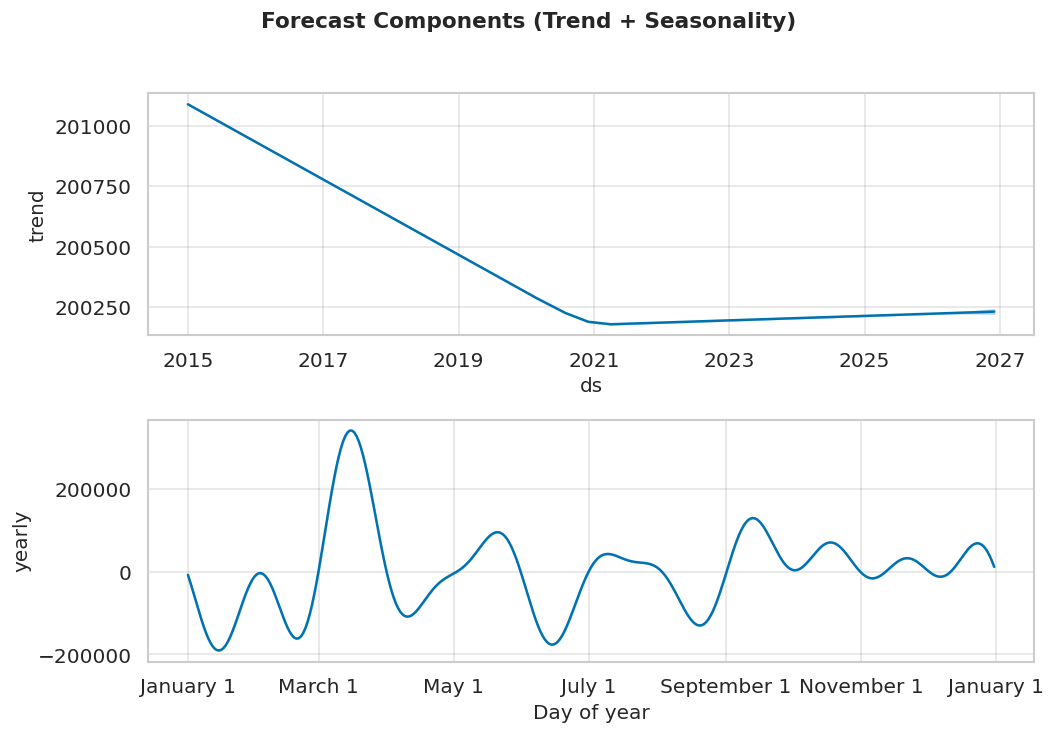

In [89]:
if USE_PROPHET:
    fig2 = m.plot_components(forecast)
    fig2.suptitle('Forecast Components (Trend + Seasonality)', fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

In [90]:
if not USE_PROPHET:
    try:
        from statsmodels.tsa.arima.model import ARIMA
        
        ts_series = ts.set_index('ds')['y']
        arima_model = ARIMA(ts_series, order=(1, 1, 1)).fit()
        forecast_arima = arima_model.forecast(steps=12)
        
        fig, ax = plt.subplots(figsize=(16, 5))
        ax.plot(ts_series, label='Historical', color='steelblue')
        ax.plot(forecast_arima, label='ARIMA Forecast', color='darkorange', linestyle='--')
        ax.set_title('ARIMA(1,1,1) - 12 Month Forecast')
        ax.legend()
        plt.tight_layout()
        plt.show()
    except ImportError:
        print('statsmodels also not available. Please install prophet or statsmodels.')

In [93]:
final_r2 = r2_score(y_test, champion_preds)
final_mae = mean_absolute_error(y_test, champion_preds)
final_rmse = np.sqrt(mean_squared_error(y_test, champion_preds))

print('FINAL RESULTS SUMMARY')
print(f'Best Model    : {champion_name}')
print(f'R2 Score      : {final_r2:.4f}')
print(f'MAE           : {final_mae:.2f}')
print(f'RMSE          : {final_rmse:.2f}')
print(f'Key Feature   : Production_Units')
print(f'Top Region    : North America')
print(f'Top Model     : Model 3 / Model Y')
print(f'2026 Forecast : continued growth expected')


FINAL RESULTS SUMMARY
Best Model    : Tuned Gradient Boosting
R2 Score      : 0.9931
MAE           : 252.25
RMSE          : 320.79
Key Feature   : Production_Units
Top Region    : North America
Top Model     : Model 3 / Model Y
2026 Forecast : continued growth expected
